# Create Spectrograms from `detect_bats.py` outputs (1-sec .wav)

5 clips


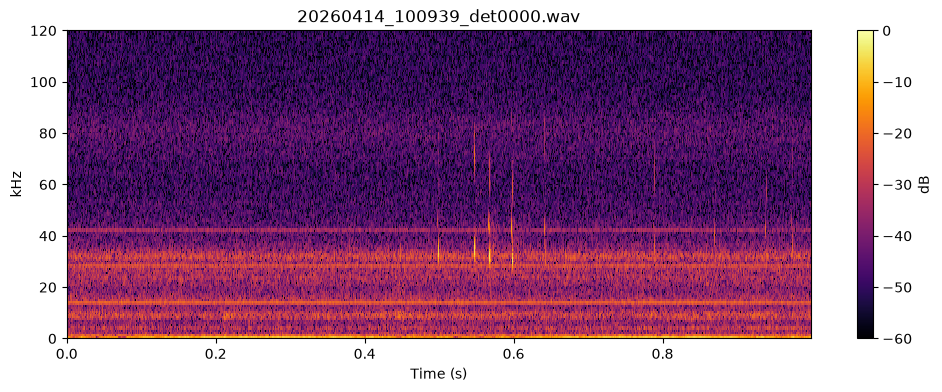

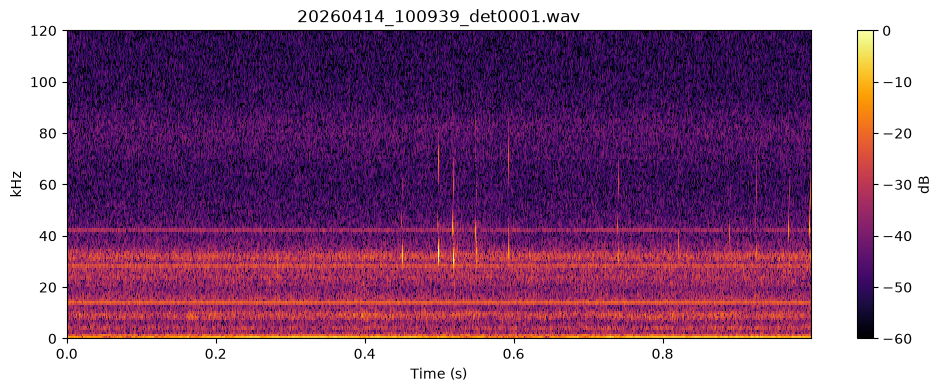

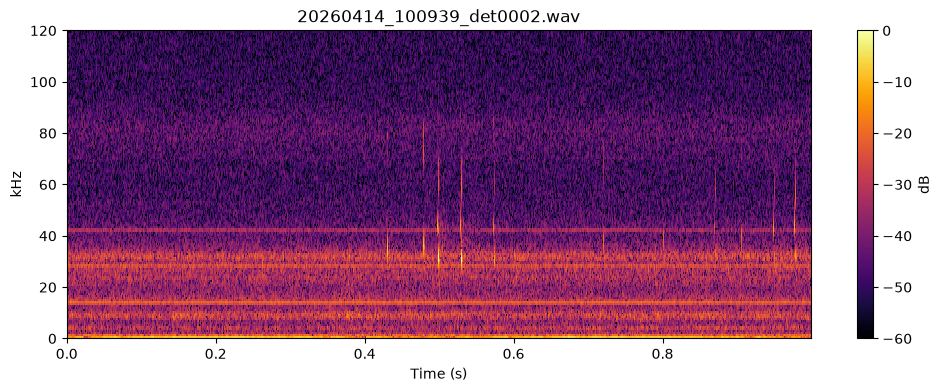

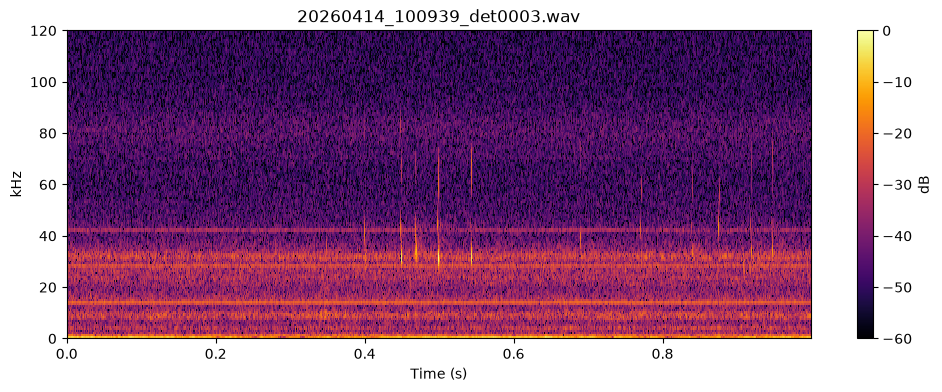

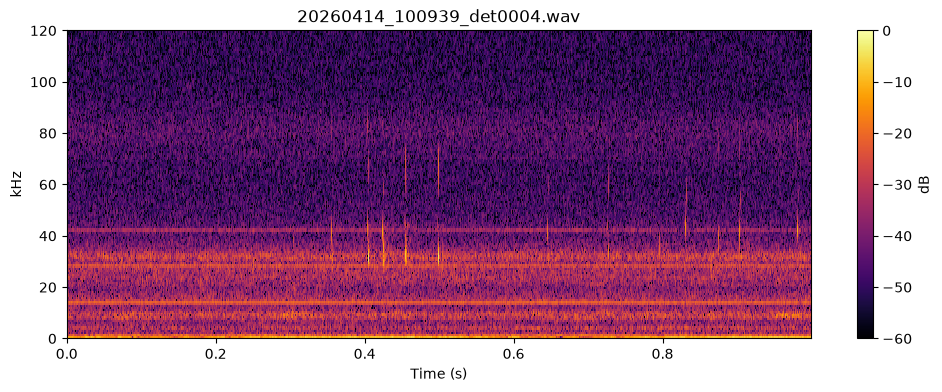

In [ ]:
# FIRST: see the detected_clips:
import glob, os, numpy as np, soundfile as sf, matplotlib.pyplot as plt

clips = sorted(glob.glob("/home/jgersey/SageBat/detected_clips/*.wav"))
print(len(clips), "clips")

N_FFT, HOP = 512, 128
win = np.hanning(N_FFT)

for path in clips[:12]:
    x, sr = sf.read(path, dtype="float64", always_2d=True)
    x = np.ascontiguousarray(x[:, 0])
    n = 1 + (len(x) - N_FFT) // HOP
    fr = np.lib.stride_tricks.as_strided(
        x, shape=(n, N_FFT), strides=(x.strides[0]*HOP, x.strides[0]))
    p = np.abs(np.fft.rfft(fr * win, axis=1))**2
    db = 10*np.log10(np.maximum(p, p.max()*1e-12)); db -= db.max()
    f = np.fft.rfftfreq(N_FFT, 1/sr)/1000
    t = np.arange(n)*HOP/sr

    plt.figure(figsize=(12, 4))
    plt.pcolormesh(t, f, db.T, shading="auto", cmap="inferno", vmin=-60, vmax=0)
    plt.ylim(0, 120)
    plt.title(os.path.basename(path))
    plt.xlabel("Time (s)"); plt.ylabel("kHz")
    plt.colorbar(label="dB")
    plt.show()